# Lesson 3: Explainable AI with SHAP

## SHAP Explainability for a Neural Network with Synthetic Energy Data

This notebook presents a structured explainable AI lesson for the neural-network model used in the smart-city and energy-management examples.

The lesson applies SHAP in the same energy-demand classification context:

- predict whether a building is likely to have high energy demand
- train a neural network on synthetic energy-style data
- explain the model globally and locally with SHAP

The explainability component addresses two questions:

- **Global explanation**: which features matter most overall?
- **Local explanation**: why did the model make one specific prediction?

## Step 1: Import the Required Tools

This step imports the libraries required for synthetic data generation, model training, evaluation, visualization, and SHAP-based explanation.

- `random` and `numpy` help us create and manage synthetic data.
- `dataclass` gives us a simple sample structure.
- `sklearn` provides scaling, the neural-network model, and evaluation metrics.
- `shap` provides explainability tools for global and local interpretation.

In [2]:
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import shap
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

## Step 2: Create a `Sample` Class

Each sample stores:

- `features`: the input feature vector
- `label`: the expected class

In [3]:
@dataclass
class Sample:
    # Step 2.1: Store the feature vector for one observation.
    features: list[float]

    # Step 2.2: Store the correct binary label.
    label: int

## Step 3: Define Helper Functions for Feature Preparation

We first build simple normalization functions so the synthetic features are numerically well behaved.

In [4]:
def normalize_temperature(temp_c: float) -> float:
    """
    Step 3.1:
    Normalize temperature to a compact range.
    """
    return (temp_c - 10.0) / 25.0


def normalize_occupancy(occupancy: int) -> float:
    """
    Step 3.2:
    Convert occupancy into a value between 0 and 1.
    """
    return occupancy / 100.0

## Step 4: Generate One Synthetic Energy Sample

This function creates one artificial observation for the smart-energy lesson.

We use:

- temperature
- occupancy
- business hours
- weekday status
- a nonlinear interaction term


In [5]:
def generate_sample() -> Sample:
    """
    Step 4:
    Create one synthetic sample for the XAI lesson.
    """
    temperature = random.uniform(8.0, 38.0)
    occupancy = random.randint(5, 100)
    hour = random.randint(0, 23)
    is_weekday = random.randint(0, 1)

    business_hours = 1 if 8 <= hour <= 18 else 0
    interaction_term = normalize_temperature(temperature) * normalize_occupancy(occupancy)

    energy_score = (
        0.7 * normalize_temperature(temperature)
        + 1.0 * normalize_occupancy(occupancy)
        + 0.5 * business_hours
        + 0.3 * is_weekday
        + 0.9 * interaction_term
        + random.uniform(-0.20, 0.20)
    )

    high_demand = 1 if energy_score > 1.45 else 0

    features = [
        normalize_temperature(temperature),
        normalize_occupancy(occupancy),
        float(business_hours),
        float(is_weekday),
        interaction_term,
    ]

    return Sample(features=features, label=high_demand)

## Step 5: Generate a Full Dataset

A neural network needs many observations, so we repeat the synthetic-sample process multiple times.

In [6]:
def generate_dataset(size: int) -> list[Sample]:
    """
    Step 5:
    Create a dataset of synthetic energy samples.
    """
    return [generate_sample() for _ in range(size)]

## Step 6: Convert Samples into Arrays

Scikit-learn works with feature matrices and target vectors, so we convert the custom `Sample` objects into arrays.

In [7]:
def samples_to_arrays(dataset: list[Sample]) -> tuple[np.ndarray, np.ndarray]:
    """
    Step 6:
    Convert the dataset into X and y arrays.
    """
    X = np.array([sample.features for sample in dataset], dtype=float)
    y = np.array([sample.label for sample in dataset], dtype=int)
    return X, y

## Step 7: Prepare Evaluation Functions

We will still evaluate the neural network as a classifier before explaining it.

This gives us:

- accuracy
- precision
- recall
- F1-score
- confusion matrix
- classification report

In [8]:
def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Step 7:
    Compute a complete set of classification metrics.
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred, zero_division=0),
    }

## Step 8: Create the Training and Test Data

We generate training and test sets and keep the random seed fixed for reproducibility.

In [9]:
# Step 8.1: Fix the random seed for reproducibility.
random.seed(42)
np.random.seed(42)

# Step 8.2: Generate the datasets.
train_data = generate_dataset(400)
test_data = generate_dataset(120)

# Step 8.3: Convert them into arrays.
X_train, y_train = samples_to_arrays(train_data)
X_test, y_test = samples_to_arrays(test_data)

# Step 8.4: Define readable feature names for evaluation and explanation.
feature_names = [
    "temperature",
    "occupancy",
    "business_hours",
    "weekday",
    "temp_occupancy_interaction",
]

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Feature names: {feature_names}")

Training samples: 400
Test samples: 120
Feature names: ['temperature', 'occupancy', 'business_hours', 'weekday', 'temp_occupancy_interaction']


## Step 9: Standardize the Input Features

Neural networks often perform better when features are scaled.

We fit the scaler on the training set and apply the same transformation to the test set.

In [10]:
# Step 9.1: Create the scaler.
scaler = StandardScaler()

# Step 9.2: Fit on training data and transform both sets.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Step 10: Build the Neural Network Model

We create a small multi-layer perceptron classifier.

The hidden layers let the model capture more complex relationships than a single perceptron.

In [11]:
# Step 10.1: Create the neural-network classifier.
model = MLPClassifier(
    hidden_layer_sizes=(8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42,
)

print(model)

MLPClassifier(hidden_layer_sizes=(8, 4), learning_rate_init=0.01, max_iter=1000,
              random_state=42)


## Step 11: Train the Neural Network

We now fit the model to the scaled training data.

In [12]:
# Step 11: Train the neural network.
model.fit(X_train_scaled, y_train)

print("Neural-network training completed.")
print(f"Training iterations used: {model.n_iter_}")
print(f"Final training loss: {model.loss_:.4f}")

Neural-network training completed.
Training iterations used: 275
Final training loss: 0.0678


## Step 12: Evaluate the Neural Network Before Explanation

We first verify that the model performs reasonably well before explaining its behavior.

In [13]:
# Step 12.1: Generate predictions.
train_predictions = model.predict(X_train_scaled)
test_predictions = model.predict(X_test_scaled)

# Step 12.2: Evaluate the predictions.
train_results = evaluate_predictions(y_train, train_predictions)
test_results = evaluate_predictions(y_test, test_predictions)

# Step 12.3: Print the main classification scores.
print("Training scores")
print(f"Accuracy:  {train_results['accuracy']:.2%}")
print(f"Precision: {train_results['precision']:.2%}")
print(f"Recall:    {train_results['recall']:.2%}")
print(f"F1-score:  {train_results['f1']:.2%}")

print("\nTest scores")
print(f"Accuracy:  {test_results['accuracy']:.2%}")
print(f"Precision: {test_results['precision']:.2%}")
print(f"Recall:    {test_results['recall']:.2%}")
print(f"F1-score:  {test_results['f1']:.2%}")

print("\nTest confusion matrix")
print(test_results['confusion_matrix'])

print("\nTest classification report")
print(test_results['classification_report'])

Training scores
Accuracy:  97.00%
Precision: 98.62%
Recall:    95.98%
F1-score:  97.29%

Test scores
Accuracy:  94.17%
Precision: 96.77%
Recall:    92.31%
F1-score:  94.49%

Test confusion matrix
[[53  2]
 [ 5 60]]

Test classification report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94        55
           1       0.97      0.92      0.94        65

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



## Step 13: Build a SHAP Explainer

SHAP explains a model by measuring how much each feature contributes to a prediction.

For this lesson we explain the **predicted probability of class 1**.

Because SHAP can be computationally expensive, we use a small background sample from the training data.

In [14]:
# Step 13.1: Create a prediction function that returns the probability of class 1.
def predict_high_demand_probability(data: np.ndarray) -> np.ndarray:
    """
    Return the probability that each sample belongs to class 1.
    """
    return model.predict_proba(data)[:, 1]


# Step 13.2: Use a subset of the scaled training data as SHAP background data.
background_data = X_train_scaled[:80]

# Step 13.3: Build the SHAP explainer.
explainer = shap.Explainer(predict_high_demand_probability, background_data, feature_names=feature_names)

print(type(explainer))

<class 'shap.explainers._exact.ExactExplainer'>


## Step 14: Compute SHAP Values for Test Samples

We now generate SHAP values for a subset of the test set.

This subset is enough to demonstrate both global and local explainability while keeping the example manageable.

In [15]:
# Step 14.1: Select a small explainability subset from the test data.
X_explain = X_test_scaled[:40]
y_explain = y_test[:40]

# Step 14.2: Compute SHAP values for that subset.
shap_values = explainer(X_explain)

print(shap_values.shape)

(40, 5)


## Step 15: Global Explanation with SHAP

A global explanation answers:

- which features are most important overall?
- which features tend to push predictions upward or downward?

Two useful plots are:

- a **bar plot** for average importance
- a **beeswarm plot** for importance and direction

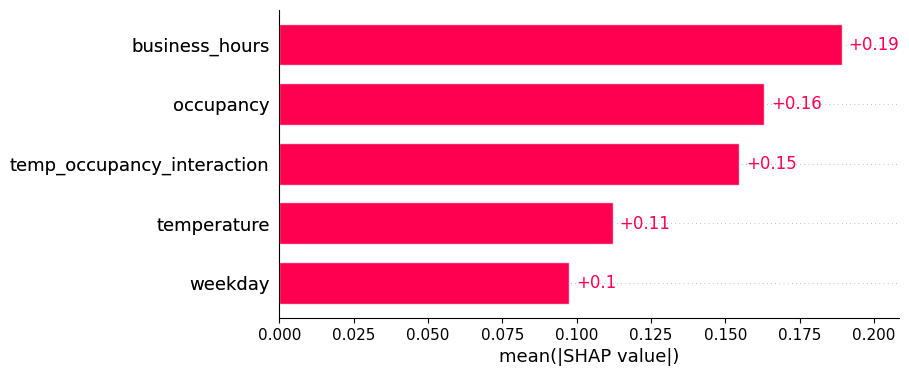

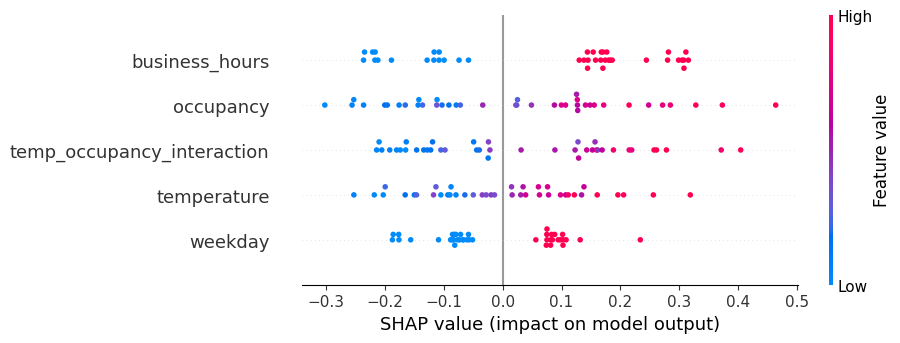

In [16]:
# Step 15.1: Global feature importance as a SHAP bar plot.
shap.plots.bar(shap_values)

# Step 15.2: Global distribution of SHAP values.
shap.plots.beeswarm(shap_values)

## Step 16: Local Explanation for One Prediction

A local explanation answers:

- why did the model classify this one case as high demand or not high demand?

We will inspect the first explained test sample with:

- its predicted probability
- its actual label
- a SHAP waterfall plot

Actual label: 1
Predicted class: 0
Predicted probability of high demand: 0.1627


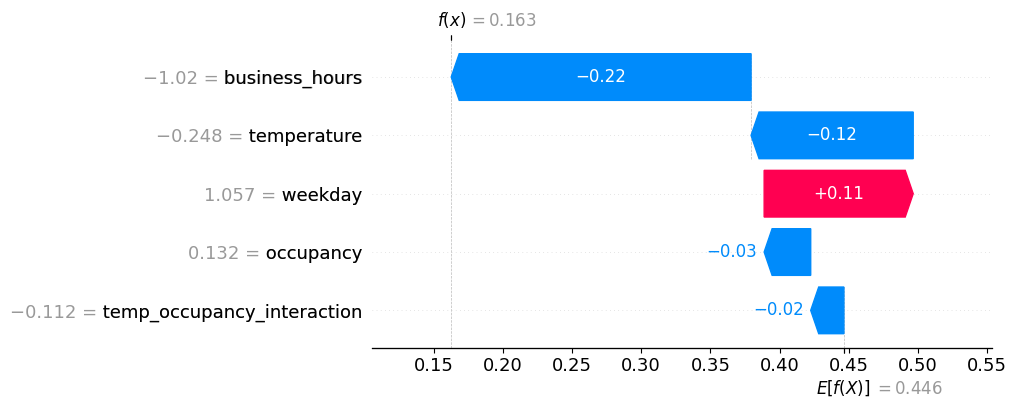

In [ ]:
# Step 16.1: Choose one sample for local explanation.
sample_index = 0

# Step 16.2: Print model output for that sample.
sample_probability = predict_high_demand_probability(X_explain[[sample_index]])[0]
sample_prediction = model.predict(X_explain[[sample_index]])[0]

print(f"Actual label: {y_explain[sample_index]}")
print(f"Predicted class: {sample_prediction}")
print(f"Predicted probability of high demand: {sample_probability:.4f}")

# Step 16.3: Show the SHAP waterfall plot for one prediction.
shap.plots.waterfall(shap_values[sample_index])

## Step 17: Compare Local Explanations for Two Samples

Sometimes it is useful to compare how the model reasons across different cases.

Below, we display the SHAP values for two samples side by side in text form.

In [18]:
# Step 17: Print feature contributions for two samples.
for index in [0, 1]:
    print(f"\nSample {index}")
    print(f"Actual label: {y_explain[index]}")
    print(f"Predicted probability: {predict_high_demand_probability(X_explain[[index]])[0]:.4f}")
    print("Feature contributions:")
    for feature_name, feature_value, shap_value in zip(feature_names, X_explain[index], shap_values.values[index]):
        print(f"  {feature_name}: value={feature_value:.3f}, shap={shap_value:.4f}")


Sample 0
Actual label: 0
Predicted probability: 0.0157
Feature contributions:
  temperature: value=0.597, shap=0.0625
  occupancy: value=-1.608, shap=-0.3016
  business_hours: value=0.980, shap=0.1439
  weekday: value=-0.946, shap=-0.1559
  temp_occupancy_interaction: value=-0.870, shap=-0.1797

Sample 1
Actual label: 1
Predicted probability: 0.1627
Feature contributions:
  temperature: value=-0.248, shap=-0.1171
  occupancy: value=0.132, shap=-0.0337
  business_hours: value=-1.020, shap=-0.2166
  weekday: value=1.057, shap=0.1077
  temp_occupancy_interaction: value=-0.112, shap=-0.0240


## Step 18: Optional Dependence Plot

A dependence plot helps us see how one feature's value relates to its SHAP contribution across many samples.

Here we inspect the relationship for `occupancy`.

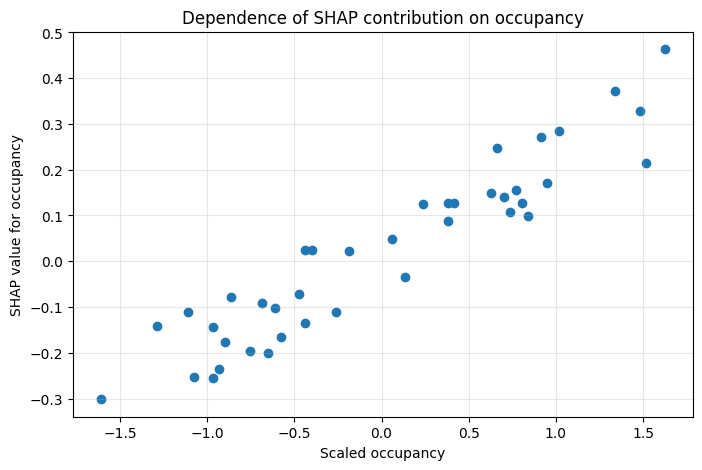

In [19]:
# Step 18: Create a simple dependence scatter plot for one feature.
occupancy_index = feature_names.index("occupancy")

plt.figure(figsize=(8, 5))
plt.scatter(X_explain[:, occupancy_index], shap_values.values[:, occupancy_index])
plt.xlabel("Scaled occupancy")
plt.ylabel("SHAP value for occupancy")
plt.title("Dependence of SHAP contribution on occupancy")
plt.grid(True, alpha=0.3)
plt.show()